# The normal Zeeman effect -- a magnetic field splits a spectral line into three
### quantized angular momentum + the Bohr magneton, with a SymPy loop over the sublevels

Put an atom in a magnetic field and its spectral lines split. The orbital magnetic
moment $\boldsymbol\mu=-\tfrac{\mu_B}{\hbar}\mathbf L$ has an orientation energy
$U=-\boldsymbol\mu\cdot\mathbf B=m_l\,\mu_B B$, so each level fans into $2l+1$
**equally spaced** sublevels ($m_l=-l\dots+l$). Classically the field exerts a torque
$\boldsymbol\tau=\boldsymbol\mu\times\mathbf B$ (the same `dipole_torque` from
magnetostatics) that makes the moment **precess**; quantum-mechanically $m_l$ is
**quantized**, so the splitting is discrete. The selection rule $\Delta m_l\in\{-1,0,+1\}$
then collapses every transition to just **three** observed lines -- the Lorentz
triplet -- spaced by the Larmor frequency $\Delta\nu=\mu_B B/h$. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sympy as sp
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from griffiths import atomic as at
sp.init_printing()
print(f"Bohr magneton mu_B = {at.bohr_magneton():.4e} J/T")

Bohr magneton mu_B = 9.2740e-24 J/T


## 1. The energy shift and the Bohr magneton

Each sublevel shifts by $\Delta E=m_l\,\mu_B B$. The Bohr magneton
$\mu_B=\dfrac{e\hbar}{2m_e}\approx9.274\times10^{-24}$ J/T is the natural unit -- one
quantum of orbital magnetic moment. At 1 tesla the sublevel spacing is tiny in
energy ($\sim58\ \mu$eV) but a clean $\sim14$ GHz in frequency.

In [2]:
B = 1.0
print(f"level spacing  mu_B B      = {at.level_spacing(B):.3e} J = {at.level_spacing(B)/1.602e-19*1e6:.2f} ueV")
print(f"line spacing   Delta_nu    = mu_B B / h = {at.larmor_frequency(B)/1e9:.3f} GHz")
print(f"normal triplet about 500 THz: {np.round(at.normal_zeeman_lines(500e12, B)/1e12, 4)} THz")

level spacing  mu_B B      = 9.274e-24 J = 57.89 ueV
line spacing   Delta_nu    = mu_B B / h = 13.996 GHz
normal triplet about 500 THz: [499.986 500.    500.014] THz


## 2. SymPy: loop over the $2l+1$ sublevels (init_printing)

For $l=10$ the level splits into **21** sublevels. Looping over every $m_l$ and
printing the symbolic shift $m_l\,\mu_B B$ shows the perfectly even ladder -- the
hallmark of the *normal* Zeeman effect. (Crank $l$ up toward 31 for the full 63.)

In [3]:
l = 10                                   # 2l+1 = 21 sublevels (between 5 and 64)
shifts = at.zeeman_shift_symbolic(l)     # list of (m_l, m_l*mu_B*B)
for m, expr in shifts:
    display(sp.Eq(sp.Symbol(f"DeltaE_{{{m:+d}}}"), expr))
mu_B, Bs = sp.symbols("mu_B B", positive=True)
gaps = [sp.simplify(shifts[i+1][1] - shifts[i][1]) for i in range(len(shifts)-1)]
print(f"\nall {len(shifts)} shifts are m_l*mu_B*B; every gap = {gaps[0]} (uniform ladder)")
assert all(g == mu_B*Bs for g in gaps)


all 21 shifts are m_l*mu_B*B; every gap = B*mu_B (uniform ladder)


## 3. The level diagram -- a fan that opens with B

Plot the $2l+1$ sublevel energies vs field strength: straight lines through zero
with slopes $m_l\,\mu_B$. At $B=0$ they are degenerate (one level); the field
**lifts the degeneracy**, fanning them apart linearly.

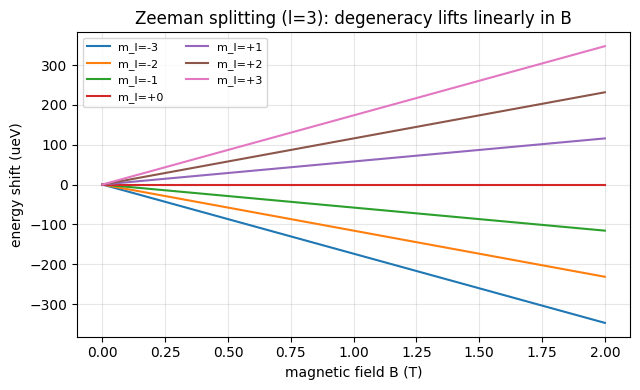

In [4]:
Bvec = np.linspace(0, 2, 100)
plt.figure(figsize=(6.5, 4))
for m in range(-3, 4):                    # l=3 -> 7 sublevels, clearer to view
    plt.plot(Bvec, at.zeeman_energy_shift(m, Bvec)/1.602e-19*1e6, label=f"m_l={m:+d}")
plt.xlabel("magnetic field B (T)"); plt.ylabel("energy shift (ueV)")
plt.title("Zeeman splitting (l=3): degeneracy lifts linearly in B"); plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. Why only THREE lines -- the Lorentz triplet

Both the upper and lower levels split into evenly spaced ladders with the *same*
spacing $\mu_B B$. The selection rule $\Delta m_l\in\{-1,0,+1\}$ allows only three
distinct transition frequencies: $\nu_0-\Delta\nu$, $\nu_0$, $\nu_0+\Delta\nu$. So no
matter how many sublevels, you see exactly three lines, the outer two splitting away
from the original linearly in $B$.

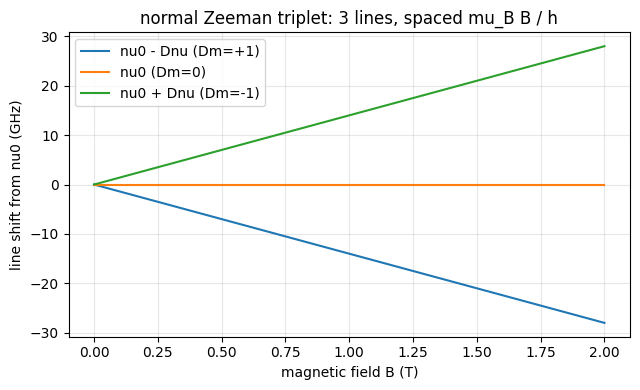

at B=1 T the outer lines sit +/- 14.00 GHz from the original


In [5]:
nu0 = 500e12
plt.figure(figsize=(6.5, 4))
for k, lbl in zip((-1, 0, 1), ("nu0 - Dnu (Dm=+1)", "nu0 (Dm=0)", "nu0 + Dnu (Dm=-1)")):
    plt.plot(Bvec, (nu0 + k*at.larmor_frequency(Bvec) - nu0)/1e9, label=lbl)
plt.xlabel("magnetic field B (T)"); plt.ylabel("line shift from nu0 (GHz)")
plt.title("normal Zeeman triplet: 3 lines, spaced mu_B B / h"); plt.legend()
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"at B=1 T the outer lines sit +/- {at.larmor_frequency(1.0)/1e9:.2f} GHz from the original")

## What the Zeeman effect shows

1. **Angular momentum is quantized:** the level splits into a discrete, evenly spaced
   $2l+1$ ladder, $\Delta E=m_l\,\mu_B B$ -- not a continuous smear.
2. **The Bohr magneton** $\mu_B=e\hbar/2m_e$ sets the scale ($\sim$14 GHz/T).
3. **Three lines, always** (normal Zeeman): the selection rule collapses the many
   sublevels to the Lorentz triplet, spaced $\mu_B B/h$.
4. It is the quantum face of the classical **torque + Larmor precession**
   ($\boldsymbol\tau=\boldsymbol\mu\times\mathbf B$) -- and it is how we *measure*
   magnetic fields from starlight and run optical magnetometers.

Same magnetic-moment physics as `griffiths.magnetostatics.dipole_torque`, now with
angular momentum quantized. Civilian education / atomic physics.